# Cycler Usage

A single entry **Cycler** object can be used to easily cycle over a single style. To create the Cycler use the **cycler()** function to link a keyword argument to a series of values.

In [2]:
from __future__ import print_function
from cycler import cycler

color_cycle = cycler(color=["r", "g", "b"])
print(color_cycle)

cycler('color', ['r', 'g', 'b'])


The Cycler knows its length and keys:

In [3]:
len(color_cycle)

3

In [4]:
color_cycle.keys

{'color'}

We can iterate over the Cycler object, the result being a series of **dict** objects, keyed on the label:

In [5]:
for v in color_cycle:
    print(v)

{'color': 'r'}
{'color': 'g'}
{'color': 'b'}


Using an existing Cycler as the argument to the cycler() function, we get a new Cycler with:

- a new label but
- the same values

In [7]:
print(cycler(ec=color_cycle))

cycler('ec', ['r', 'g', 'b'])


Above, we iterated over the Cycler object returning the finite set (3) of the values. To get an infinite cycle, use it as a generator.

In [8]:
cc = color_cycle()

for j, c in zip(range(5), cc):
    print(j, c)

0 {'color': 'r'}
1 {'color': 'g'}
2 {'color': 'b'}
3 {'color': 'r'}
4 {'color': 'g'}


# Composition

So, why not use a simple for-loop instead of a Cycler? Because with a Cycler we can compose complex multi-key cycles.

## Addition
We can "add" cyclers having equal length but different keys.<br/>
The result has keys which are the **union of the two input cyclers**.

In [12]:
lw_cycle = cycler(lw=range(1, 4))  # len is 3
wc = lw_cycle + color_cycle  # len is 3

print(len(wc))
print(wc.keys)

3
{'lw', 'color'}


Iterate over the result and you get the **zip** of the two cyclers

In [13]:
for s in wc:
    print(s)

{'lw': 1, 'color': 'r'}
{'lw': 2, 'color': 'g'}
{'lw': 3, 'color': 'b'}


Addition is commutative (as with plain arithmetic)

In [14]:
lw_c = lw_cycle + color_cycle
c_lw = color_cycle + lw_cycle

for j, (a, b) in enumerate(zip(lw_c, c_lw)):
    print(f"({j}) A: {a} B: {b}")

(0) A: {'lw': 1, 'color': 'r'} B: {'color': 'r', 'lw': 1}
(1) A: {'lw': 2, 'color': 'g'} B: {'color': 'g', 'lw': 2}
(2) A: {'lw': 3, 'color': 'b'} B: {'color': 'b', 'lw': 3}


Instead of passing one key-value pair to the cycler(), we can pass multiple ones

In [15]:
wc = cycler(c=["r", "g", "b"], lw=range(3))

for s in wc:
    print(s)

{'c': 'r', 'lw': 0}
{'c': 'g', 'lw': 1}
{'c': 'b', 'lw': 2}


## Multiplication

Get the **outer product** of the two cyclers

In [17]:
m_cycle = cycler(marker=["s", "o"])
m_c = m_cycle * color_cycle

print(len(m_c))
print(m_c.keys)

6
{'marker', 'color'}


In [18]:
for s in m_c:
    print(s)

{'marker': 's', 'color': 'r'}
{'marker': 's', 'color': 'g'}
{'marker': 's', 'color': 'b'}
{'marker': 'o', 'color': 'r'}
{'marker': 'o', 'color': 'g'}
{'marker': 'o', 'color': 'b'}


Multiplication is not commutative, so<br/>
m_cycle * color_cycle is not the same as <br/>
color_cycle * m_cycle

## Integer Multiplication

In [20]:
print(color_cycle * 2)

cycler('color', ['r', 'g', 'b', 'r', 'g', 'b'])


## Concatenation

In [22]:
print(color_cycle.concat(color_cycle))

cycler('color', ['r', 'g', 'b', 'r', 'g', 'b'])


## Slicing

In [ ]:
# Reverse the order
print(color_cycle[::-1])

cycler('color', ['b', 'g', 'r'])


In [26]:
# Get the first two values
print(color_cycle[:2])

cycler('color', ['r', 'g'])


## Inspecting the Cycler

In [29]:
m_c.by_key()

{'marker': ['s', 's', 's', 'o', 'o', 'o'],
 'color': ['r', 'g', 'b', 'r', 'g', 'b']}

In [32]:
m_c

'r','s'
'g','s'
'b','s'
'r','o'
'g','o'
'b','o'


# Examples

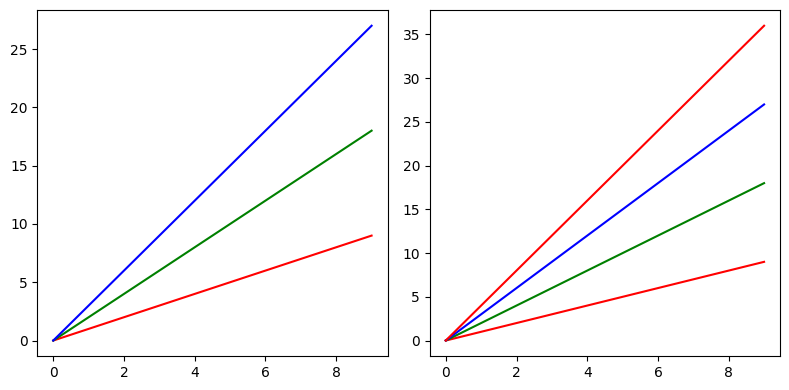

In [40]:
from cycler import cycler
from itertools import cycle
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), tight_layout=True)

x = np.arange(10)

color_cycle = cycler(c=["r", "g", "b"])

# Plot the lines y = x, y = 2x, and y = 3x
# The kwargs are respecively: c="r", c="g", and c="b"
# So, for each iteration we actuallly plot:
#   ax1.plot(x, x, c="r")
#   ax1.plot(x, 2x, c="g")
#   ax1.plot(x, 3x, c="b")
for i, sty in enumerate(color_cycle):
    ax1.plot(x, x * (i + 1), **sty)

# Plot the lines y = x, y = 2x, y = 3x, and y = 4x
# cycle() returns the items of the iterable until the end
#         and then repeats the process from the beginning.
for i, sty in zip(range(1, 5), cycle(color_cycle)):
    ax2.plot(x, x * i, **sty)

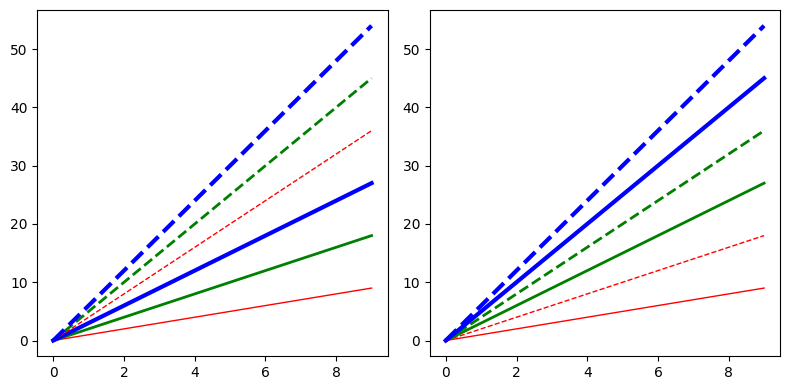

In [46]:
from cycler import cycler
from itertools import cycle

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), tight_layout=True)

x = np.arange(10)

color_cycle = cycler(c=["r", "g", "b"])
ls_cycle = cycler(ls=["-", "--"])
lw_cycle = cycler(lw=range(1, 4))

sty_cycle = ls_cycle * (color_cycle + lw_cycle)

for i, sty in enumerate(sty_cycle):
    ax1.plot(x, x * (i + 1), **sty)

sty_cycle = (color_cycle + lw_cycle) * ls_cycle

for i, sty in enumerate(sty_cycle):
    ax2.plot(x, x * (i + 1), **sty)

# Persistent Cycles

In [47]:
from cycler import cycler as cy
from collections import defaultdict

cyl = cy("c", "rgb") + cy("lw", range(1, 4))

Get a finite set of styles

In [48]:
finite_cy_iter = iter(cyl)
dd_finite = defaultdict(lambda: next(finite_cy_iter))

# Motivation

How to cycle over one or more artist styles.

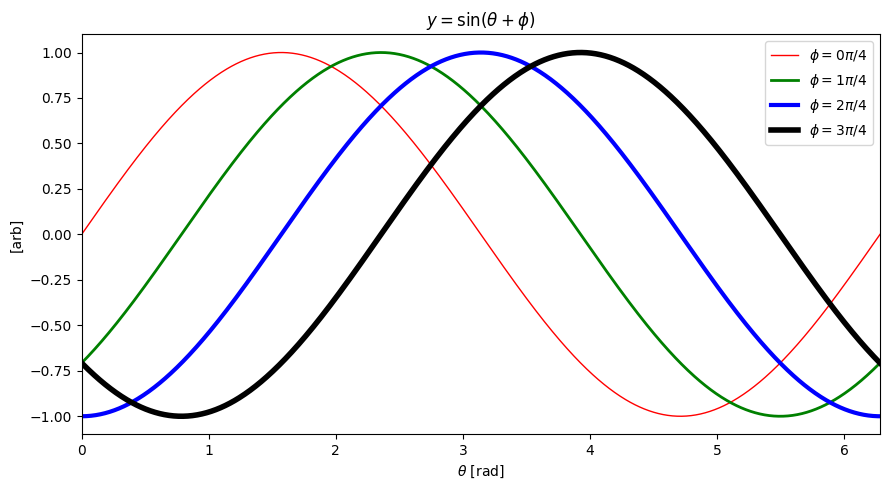

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5), tight_layout=True)
x = np.linspace(0, 2 * np.pi, 1024)

# Plots the graphs:
#   y = sin(x)
#   y = sin(x-π/4)
#   y = sin(x-2π/4)
#   y = sin(x-3π/4)
for i, (lw, c) in enumerate(zip(range(4), ["r", "g", "b", "k"])):
    ax.plot(
        x,
        np.sin(x - i * np.pi / 4),
        label=f"$\\phi = {i} \\pi / 4$",
        lw=lw + 1,
        c=c,
    )

ax.set_xlim([0, 2 * np.pi])
ax.set_title(r"$y=\sin(\theta + \phi)$")
ax.set_ylabel(r"[arb]")
ax.set_xlabel(r"$\theta$ [rad]")
ax.legend(loc=0)

plt.show()